In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [3]:
input_layer = Input(shape=(28,28,1))

x = Conv2D(32,(3,3),activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(64,(3,3),activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Flatten()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(10,activation='softmax')(x)

cnn_model = Model(inputs=input_layer, outputs=output)
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [4]:
history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.9265 - loss: 0.2509 - val_accuracy: 0.9415 - val_loss: 0.1987
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9721 - loss: 0.0933 - val_accuracy: 0.9855 - val_loss: 0.0534
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9803 - loss: 0.0677 - val_accuracy: 0.9873 - val_loss: 0.0471
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.9837 - loss: 0.0548 - val_accuracy: 0.9880 - val_loss: 0.0441
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9898 - val_loss: 0.0411
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9887 - loss: 0.0363 - val_accuracy: 0.9895 - val_loss: 0.0461
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9915 - val_loss: 0.0400
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9895 - loss: 0.0336 - 

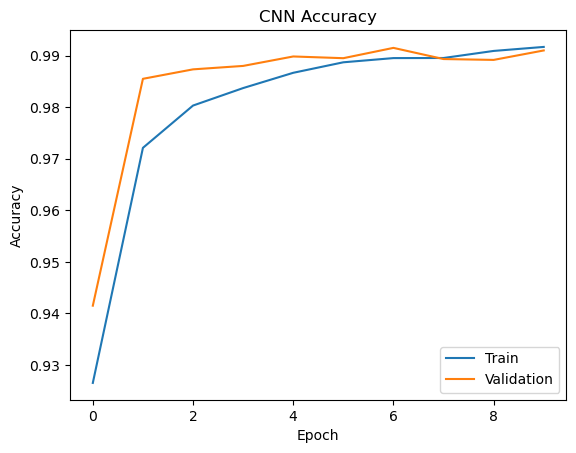

In [5]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


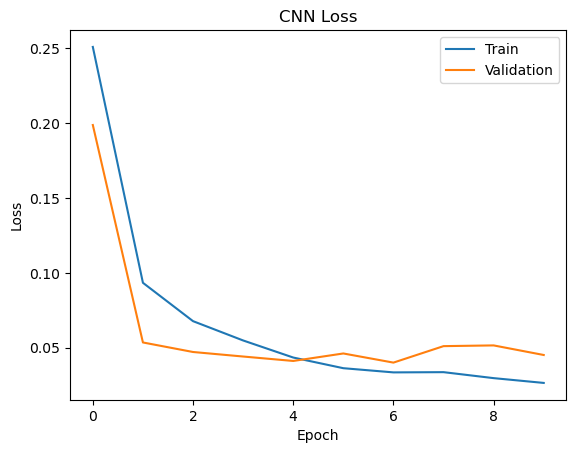

In [6]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


In [7]:
cnn_preds = cnn_model.predict(X_test)
cnn_preds_classes = np.argmax(cnn_preds, axis=1)

cnn_acc = accuracy_score(y_test, cnn_preds_classes)
print("CNN Accuracy:", cnn_acc)

print(classification_report(y_test, cnn_preds_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
CNN Accuracy: 0.9894
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.97      0.99      0.98      1028
           8       1.00      0.98      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



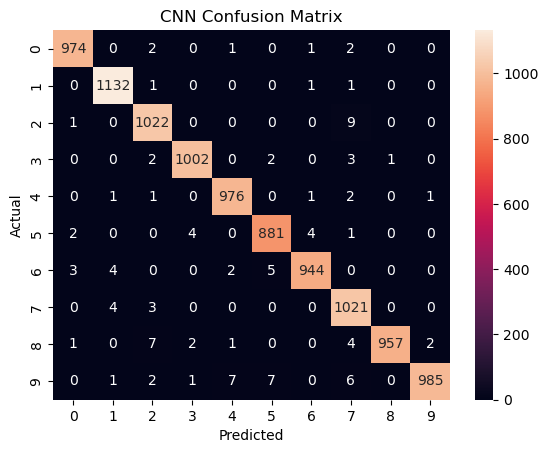

In [8]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, cnn_preds_classes),
            annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [9]:
feature_extractor = Model(inputs=cnn_model.input,
                          outputs=cnn_model.layers[-3].output)

train_features = feature_extractor.predict(X_train)
test_features = feature_extractor.predict(X_test)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [10]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='mlogloss'
)

xgb.fit(train_features, y_train)
xgb_preds = xgb.predict(test_features)

xgb_acc = accuracy_score(y_test, xgb_preds)
print("XGBoost Accuracy:", xgb_acc)

print(classification_report(y_test, xgb_preds))


XGBoost Accuracy: 0.9924
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [11]:
ada = AdaBoostClassifier(n_estimators=100)
ada.fit(train_features, y_train)

ada_preds = ada.predict(test_features)

ada_acc = accuracy_score(y_test, ada_preds)
print("AdaBoost Accuracy:", ada_acc)

print(classification_report(y_test, ada_preds))


AdaBoost Accuracy: 0.9865
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [12]:
comparison = pd.DataFrame({
    "Model": ["CNN", "XGBoost", "AdaBoost"],
    "Accuracy": [cnn_acc, xgb_acc, ada_acc]
})

print(comparison)


      Model  Accuracy
0       CNN    0.9894
1   XGBoost    0.9924
2  AdaBoost    0.9865
